In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.tv_tensors import BoundingBoxes
import torch.nn as nn
from torchvision.ops import box_iou
import torchvision.transforms.v2 as v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
import torchmetrics as tm
from torchvision.ops import nms
import torchvision.transforms.v2.functional as F

In [2]:
seed = 42
torch.random.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
root_path = "/home/stefan/ioai-prep/kits/spooky/haunt-me"

batch_size = 8

# Data

In [ ]:
class ContrastEnhanceTransform(nn.Module):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), blur_sigma=0.0):
        super().__init__()
        self.blur_sigma = blur_sigma
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def forward(self, *inputs):
        # The image is always the first input
        img = inputs[0]
        other_inputs = inputs[1:]

        # --- original logic applied to the image ---
        if isinstance(img, Image.Image):
            img_np = np.array(img)
            if len(img_np.shape) == 3:
                gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            else:
                gray = img_np
        else:
            gray = img

        enhanced = self.clahe.apply(gray)
        if self.blur_sigma > 0:
            enhanced = cv2.GaussianBlur(enhanced, (3, 3), self.blur_sigma)
        enhanced_img = Image.fromarray(enhanced)
        # --- end of original logic ---

        # Pass the modified image and any other data (e.g., bboxes) through
        if not other_inputs:
            return enhanced_img
        else:
            return (enhanced_img,) + other_inputs


class GrayscaleToRGB(nn.Module):
    def forward(self, *inputs):
        # The image tensor is always the first input
        img_tensor = inputs[0]
        other_inputs = inputs[1:]

        # Perform the transformation on the image tensor
        rgb_tensor = img_tensor.repeat(3, 1, 1)

        # Pass the modified tensor and any other data (e.g., bboxes) through
        if not other_inputs:
            return rgb_tensor
        else:
            return (rgb_tensor,) + other_inputs


class SpookyDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()

        self.is_train = is_train
        self.dir = f"{root_path}/{'train' if is_train else 'inference'}"
        self.files = [f for f in os.listdir(self.dir) if f.endswith(".jpg")]

        # Base transforms are applied to all images
        base_transforms = [
            ContrastEnhanceTransform(),
        ]

        # Augmentations are only for the training set
        aug_transforms = []
        if is_train:
            aug_transforms = [
                v2.RandomHorizontalFlip(p=0.5),
                v2.RandomVerticalFlip(p=0.3),
                v2.ColorJitter(brightness=0.2, contrast=0.2),
            ]

        # Final transforms that resize, convert to tensor, and normalize
        # This pipeline will apply transformations to both image and bounding box
        final_transforms = [
            v2.Resize((224, 224), antialias=True),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            GrayscaleToRGB(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]

        self.transforms = v2.Compose(
            base_transforms + aug_transforms + final_transforms
        )

        if is_train:
            self.df = pd.read_csv(f"{root_path}/train_data.csv")

    def __getitem__(self, idx):
        file = f"{self.dir}/{self.files[idx]}"
        image_id = self.files[idx][: -len(".jpg")]

        img = Image.open(file).convert("RGB")

        if not self.is_train:
            img = self.transforms(img)
            return image_id, img

        row = self.df[self.df["image_id"] == image_id].iloc[0]
        bbox_vals = row.iloc[2:6].tolist()
        label = torch.tensor(row.iloc[1], dtype=torch.long)

        # Wrap bounding box in the required torchvision tensor format
        bboxes = BoundingBoxes([bbox_vals], format="xyxy", canvas_size=(512, 512))

        # Apply all transforms to image and bounding boxes together
        img, bboxes = self.transforms(img, bboxes)

        # The bounding box is now automatically resized to the 224x224 canvas
        bbox = bboxes[0] if len(bboxes) > 0 else torch.zeros(4, dtype=torch.float32)

        return {"image": img, "label": label, "bbox": bbox}

    def __len__(self):
        return len(self.files)

In [4]:
train_ds = SpookyDataset(is_train=True)
test_ds = SpookyDataset(is_train=False)

n = len(train_ds)
n_train = int(0.8 * n)
n_val = n - n_train

train_ds, val_ds = random_split(
    train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(seed)
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [5]:
x = next(iter(train_loader))

{k:x[k].shape for k in x.keys()}

{'image': torch.Size([8, 3, 224, 224]),
 'label': torch.Size([8]),
 'bbox': torch.Size([8, 4])}

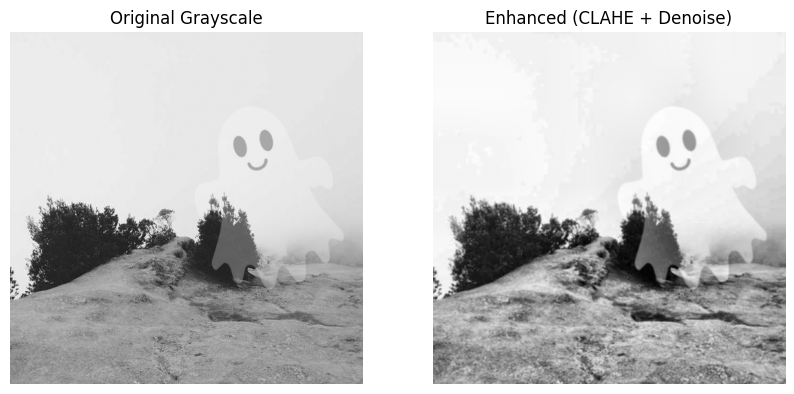

In [6]:
img_bgr = cv2.imread(f"{root_path}/train/img_0005.jpg")
if img_bgr.shape[2] == 4:
    alpha = img_bgr[:, :, 3] / 255.0
    img_bgr = img_bgr[:, :, :3]
    img_bgr = (img_bgr * alpha[:, :, np.newaxis]).astype(np.uint8)

original_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(original_gray)
denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_gray, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")
axes[1].imshow(denoised, cmap="gray")
axes[1].set_title("Enhanced (CLAHE + Denoise)")
axes[1].axis("off")
plt.show()

# Model

In [ ]:
def create_model(num_classes=2):
    model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = create_model(num_classes=2).to(device)

# Sanity check
model.eval()
with torch.no_grad():
    out = model(x["image"].to(device))
model.train()
print([o["boxes"].shape for o in out])

[torch.Size([10, 4]), torch.Size([1, 4]), torch.Size([6, 4]), torch.Size([100, 4]), torch.Size([17, 4]), torch.Size([0, 4]), torch.Size([4, 4]), torch.Size([26, 4])]


# Training

In [8]:
def prepare_targets(labels, bboxes, device):
    targets = []
    for i in range(len(labels)):
        if labels[i] == 1:
            targets.append({
               "boxes": bboxes[i].unsqueeze(0).to(device),
                "labels": torch.tensor([1], dtype=torch.long, device=device),
            })
        else: # No ghost
            targets.append({
                "boxes": torch.zeros((0, 4), dtype=torch.float32, device=device),
                "labels": torch.zeros((0,), dtype=torch.long, device=device),
            })
    return targets

In [9]:
def evaluate(model, loader, score_thresh=0.5):
    all_preds = []
    all_labels = []
    iou_list = []

    model.eval()
    with torch.no_grad():
        for b in loader:
            imgs = b["image"].to(device)
            labels = b["label"].to(device)
            # BBoxes from our corrected dataset are already in 224x224 space
            bboxes_gt = b["bbox"].to(device)

            predictions = model(imgs)

            for i, pred in enumerate(predictions):
                # Use a score threshold to decide if a ghost is present
                # This is more robust than just checking for box existence
                scores = pred["scores"]
                high_conf_indices = scores > score_thresh

                has_ghost_pred = high_conf_indices.any().item()
                all_preds.append(int(has_ghost_pred))
                all_labels.append(labels[i].item())

                if labels[i] == 1 and has_ghost_pred:
                    # Get the highest scoring predicted box
                    best_box_idx = scores.argmax()
                    box_pred = pred["boxes"][best_box_idx].unsqueeze(0)

                    box_gt = bboxes_gt[i].unsqueeze(0)
                    iou = box_iou(box_pred, box_gt)[0, 0]
                    iou_list.append(iou.item())

    acc = tm.Accuracy(task="binary").to(device)
    all_preds_t = torch.tensor(all_preds, device=device)
    all_labels_t = torch.tensor(all_labels, device=device)

    return {
        "acc": acc(all_preds_t, all_labels_t).item(),
        "iou": np.mean(iou_list) if iou_list else 0.0,
    }

In [10]:
lr = 1e-3
epochs = 30

In [11]:
optim = torch.optim.AdamW(model.parameters(), lr=lr)
sched = torch.optim.lr_scheduler.OneCycleLR(
    optim, max_lr=lr, epochs=epochs,
    steps_per_epoch=len(train_loader),
)
scaler = torch.amp.GradScaler(device)

In [12]:
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader):
        imgs = batch["image"].to(device)
        labels = batch["label"].long().to(device)
        bboxes = batch["bbox"].to(device)

        targets = prepare_targets(labels, bboxes, device)

        with torch.amp.autocast(device):
            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())

        optim.zero_grad()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optim)
        scaler.update()
        sched.step()

        total_loss += loss.item()

    total_loss = total_loss / len(train_loader)
    metrics = evaluate(model, val_loader)
    print(f"Epoch {epoch}, loss={total_loss:.3f}, metrics={metrics}")

100%|██████████| 80/80 [00:21<00:00,  3.80it/s]


Epoch 1, loss=0.605, metrics={'acc': 0.7562500238418579, 'iou': np.float64(0.6636520614953975)}


100%|██████████| 80/80 [00:13<00:00,  5.96it/s]


Epoch 2, loss=0.684, metrics={'acc': 0.8812500238418579, 'iou': np.float64(0.777224046177324)}


100%|██████████| 80/80 [00:12<00:00,  6.51it/s]


...

Epoch 28, loss=0.125, metrics={'acc': 0.96875, 'iou': np.float64(0.948753940765851)}


100%|██████████| 80/80 [00:10<00:00,  7.85it/s]


Epoch 29, loss=0.135, metrics={'acc': 0.9750000238418579, 'iou': np.float64(0.9477986205736314)}


100%|██████████| 80/80 [00:10<00:00,  7.67it/s]


Epoch 30, loss=nan, metrics={'acc': 0.9624999761581421, 'iou': np.float64(0.9484208774964079)}


# Submission

Finding best threshold: 100%|██████████| 10/10 [00:20<00:00,  2.08s/it]


Best Threshold: 0.40
Validation Accuracy at Best Threshold: 0.9812


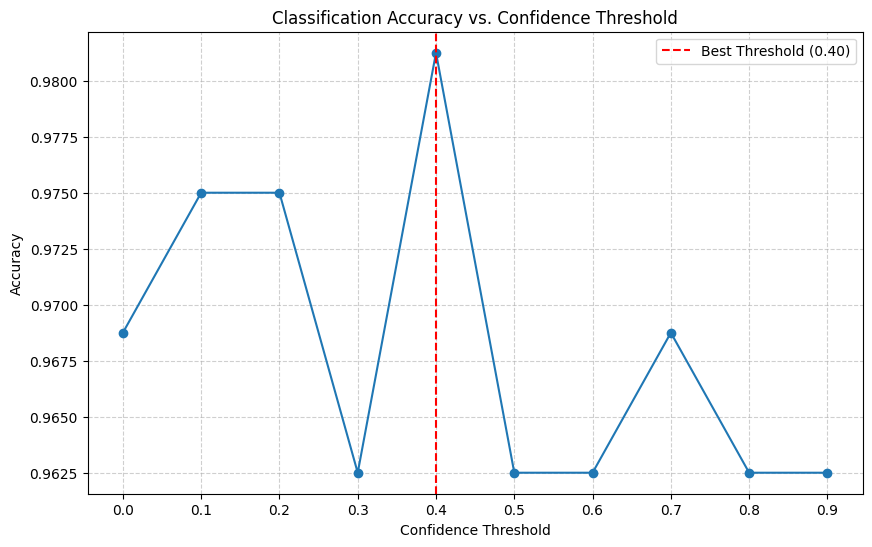

In [19]:
thresholds_to_test = np.arange(0.00, 1.0, 0.1)
accuracies = []
best_accuracy = 0
best_threshold = 0

model.eval()
with torch.no_grad():
    for thresh in tqdm(thresholds_to_test, desc="Finding best threshold"):
        all_preds = []
        all_labels = []
        for batch in val_loader:
            imgs = batch["image"].to(device)
            labels = batch["label"].to(device)

            predictions = model(imgs)

            for i, pred in enumerate(predictions):
                # Classify as 'ghost' if any detected box has a score > thresh
                scores = pred["scores"]
                has_ghost_pred = (scores > thresh).any().item()

                all_preds.append(int(has_ghost_pred))
                all_labels.append(labels[i].item())

        acc_metric = tm.Accuracy(task="binary").to(device)
        preds_tensor = torch.tensor(all_preds, device=device)
        labels_tensor = torch.tensor(all_labels, device=device)

        current_accuracy = acc_metric(preds_tensor, labels_tensor).item()
        accuracies.append(current_accuracy)

        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_threshold = thresh

print(f"\nBest Threshold: {best_threshold:.2f}")
print(f"Validation Accuracy at Best Threshold: {best_accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds_to_test, accuracies, marker="o", linestyle="-")
plt.axvline(
    x=best_threshold,
    color="r",
    linestyle="--",
    label=f"Best Threshold ({best_threshold:.2f})",
)
plt.title("Classification Accuracy vs. Confidence Threshold")
plt.xlabel("Confidence Threshold")
plt.ylabel("Accuracy")
plt.xticks(thresholds_to_test)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
def predict_with_tta(model, imgs, score_thresh, nms_iou_thresh=0.5):
    """
    Performs TTA on a batch of images and returns aggregated predictions.
    """
    height, width = imgs.shape[-2:]
    final_predictions = []

    # Define TTA transformations and their corresponding "un-transform" logic for boxes
    transform_configs = [
        {  # 1. Original Image
            "transform": lambda x: x,
            "un_transform_boxes": lambda boxes: boxes,
        },
        {  # 2. Horizontal Flip
            "transform": lambda x: F.horizontal_flip(x),
            "un_transform_boxes": lambda boxes: torch.stack(
                [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]],
                dim=1,
            ),
        },
        {  # 3. Vertical Flip
            "transform": lambda x: F.vertical_flip(x),
            "un_transform_boxes": lambda boxes: torch.stack(
                [boxes[:, 0], height - boxes[:, 3], boxes[:, 2], height - boxes[:, 1]],
                dim=1,
            ),
        },
    ]

    # Store all augmented predictions for each image in the batch
    batch_aggregated_boxes = [[] for _ in range(imgs.shape[0])]
    batch_aggregated_scores = [[] for _ in range(imgs.shape[0])]

    for config in transform_configs:
        # Apply transform and get prediction
        augmented_imgs = config["transform"](imgs)
        preds = model(augmented_imgs)

        # Un-transform boxes and store results for each image in the batch
        for i, pred in enumerate(preds):
            boxes = pred["boxes"]
            if boxes.shape[0] > 0:
                un_transformed_boxes = config["un_transform_boxes"](boxes)
                batch_aggregated_boxes[i].append(un_transformed_boxes)
                batch_aggregated_scores[i].append(pred["scores"])

    # Process each image's aggregated results
    for i in range(imgs.shape[0]):
        # Check if any boxes were detected across all augmentations
        if not batch_aggregated_boxes[i]:
            final_predictions.append(
                {
                    "boxes": torch.empty(0, 4, device=imgs.device),
                    "scores": torch.empty(0, device=imgs.device),
                }
            )
            continue

        # Merge boxes and scores from all TTAs
        merged_boxes = torch.cat(batch_aggregated_boxes[i])
        merged_scores = torch.cat(batch_aggregated_scores[i])

        # Filter out low-confidence boxes before NMS
        high_conf_mask = merged_scores > 0.01  # Use a low pre-filter threshold
        merged_boxes = merged_boxes[high_conf_mask]
        merged_scores = merged_scores[high_conf_mask]

        if merged_boxes.shape[0] == 0:
            final_predictions.append(
                {
                    "boxes": torch.empty(0, 4, device=imgs.device),
                    "scores": torch.empty(0, device=imgs.device),
                }
            )
            continue

        # Apply Non-Maximum Suppression to remove redundant boxes
        nms_indices = nms(merged_boxes, merged_scores, iou_threshold=nms_iou_thresh)

        final_boxes = merged_boxes[nms_indices]
        final_scores = merged_scores[nms_indices]

        final_predictions.append({"boxes": final_boxes, "scores": final_scores})

    return final_predictions

In [ ]:
submission_rows = []
score_thresh = best_threshold

model.eval()
with torch.no_grad():
    for image_ids, imgs in tqdm(test_loader, desc="Generating submission with TTA"):
        # Get robust predictions using our TTA function
        final_predictions = predict_with_tta(model, imgs.to(device), score_thresh)

        for img_id, pred in zip(image_ids, final_predictions):
            scores = pred["scores"]
            boxes = pred["boxes"]

            # Find boxes with confidence above our optimal threshold
            high_conf_indices = scores > score_thresh

            ghost = 1 if high_conf_indices.any() else 0
            submission_rows.append(
                {"subtaskID": 1, "datapointID": img_id, "answer": str(ghost)}
            )

            if ghost == 1:
                # Get the box with the highest score from the cleaned TTA results
                best_box_idx = scores.argmax()
                box = boxes[best_box_idx]

                # Scale box from 224x224 space to 512x512 space
                box_scaled = box * (512.0 / 224.0)
                box_scaled = box_scaled.clamp(0, 512)
                box_str = f"[{int(box_scaled[0])},{int(box_scaled[1])},{int(box_scaled[2])},{int(box_scaled[3])}]"
            else:
                box_str = "[-1,-1,-1,-1]"

            submission_rows.append(
                {"subtaskID": 2, "datapointID": img_id, "answer": box_str}
            )

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("submission.csv", index=False)
print(f"Submission saved with {len(submission_df)} rows")

Generating submission with TTA: 100%|██████████| 25/25 [00:06<00:00,  3.72it/s]

Submission saved with 400 rows
